Working directory:
/root/geant4/detector/Lung_ICRP

Input ROOT file:
/root/geant4/detector/Lung_ICRP/lung1_tissueTumor.root

Total TTree entries:
50000

Extraction summary:
Entries having an empty et vector: 46032
Total aligned et elements inspected: 14824
Volume 4: 0 selected et records
Volume 5: 15 selected et records

VOLUME 4
Only 0 et records were found. A reliable FWHM cannot be determined.

VOLUME 5
Number of selected et records: 15

Smoothed-curve result:
Maximum located at  : 517.0000 keV
Maximum height      : 0.5319 counts
Half maximum        : 0.2660 counts
Left half crossing  : 513.4563 keV
Right half crossing : 520.5437 keV
Curve FWHM          : 7.0875 keV
Curve resolution    : 1.3709%

Gaussian-fit result:
Fitted centroid     : 517.0002 keV
Fitted sigma        : 0.2708 keV
Gaussian FWHM       : 0.6377 keV
Gaussian resolution : 0.1233%


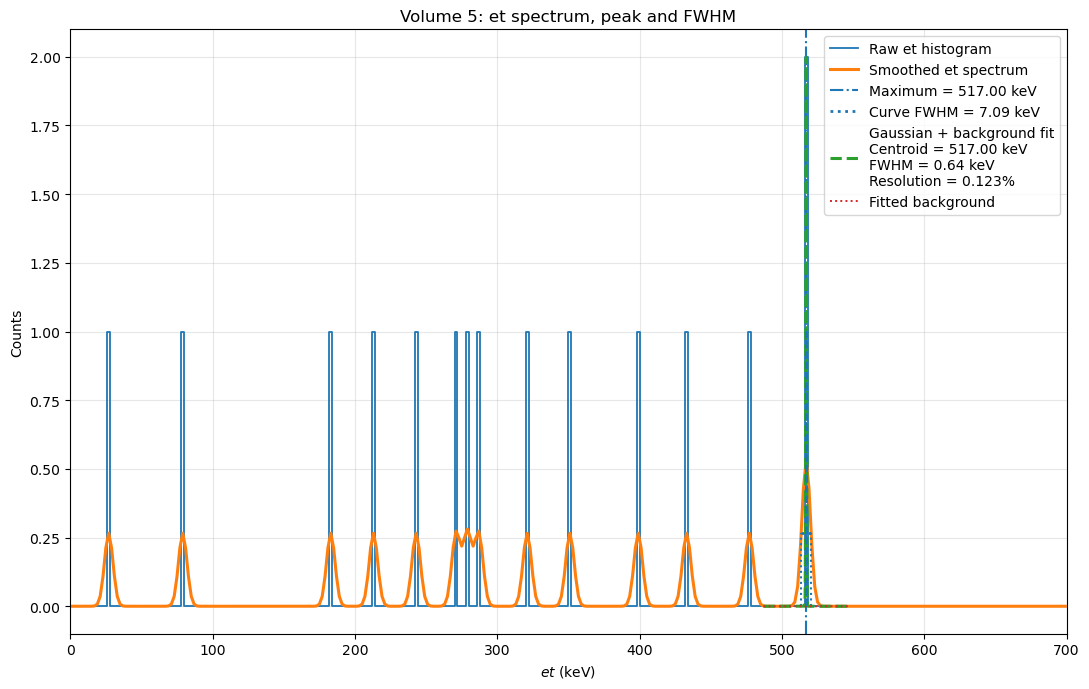

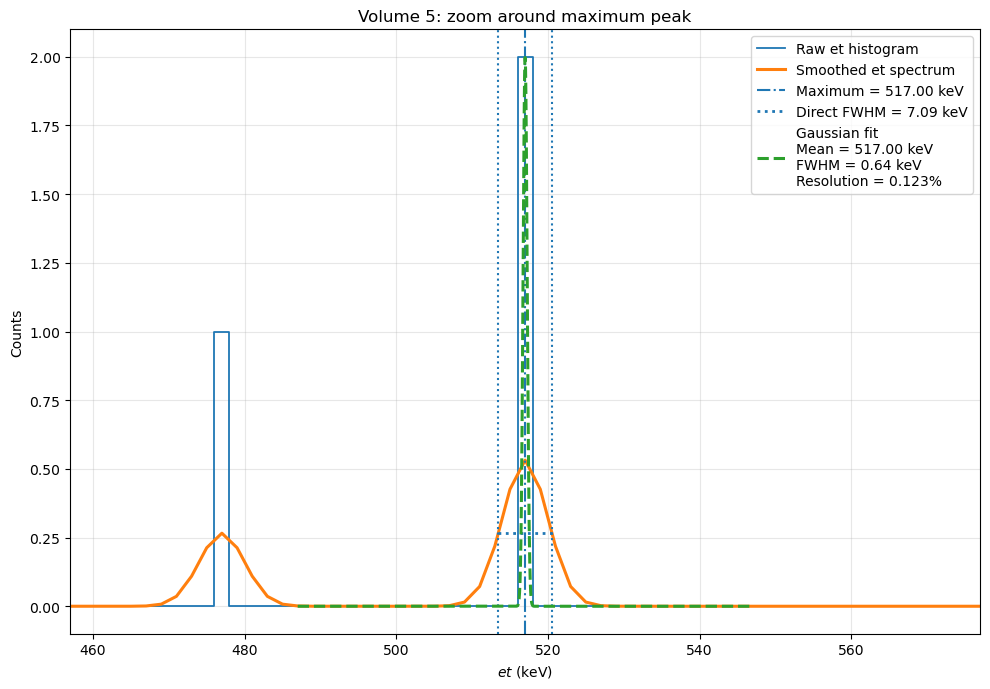


FINAL SUMMARY


,volume,number_of_et_records,curve_peak_energy_keV,curve_left_half_keV,curve_right_half_keV,curve_FWHM_keV,curve_resolution_percent,gaussian_centroid_keV,gaussian_sigma_keV,gaussian_FWHM_keV,gaussian_resolution_percent
0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,15,517.0,513.456273,520.543727,7.087454,1.370881,517.000151,0.270804,0.637694,0.123345



Summary CSV saved at:
/root/geant4/detector/Lung_ICRP/et_peak_FWHM_summary_vlm4_vlm5.csv
Volume 4 histogram CSV:
/root/geant4/detector/Lung_ICRP/et_histogram_volume4.csv
Volume 5 histogram CSV:
/root/geant4/detector/Lung_ICRP/et_histogram_volume5.csv


In [5]:
import os
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

# =====================================================
# USER SETTINGS
# =====================================================
working_directory = "/root/geant4/detector/Lung_ICRP"
file_path = "lung1_tissueTumor.root"
tree_name = "t"

selected_volumes = [4, 5]
selected_pdg = 22

# Complete displayed energy range
energy_min = 0.0
energy_max = 700.0

# Histogram bin width
# Use 1–2 keV for low statistics.
# Very small bins may make the spectrum too noisy.
bin_width = 2.0

# Gaussian smoothing width in histogram bins
# This is only for displaying and locating the peak.
smoothing_sigma_bins = 1.5

# Number of bins searched on both sides of the maximum
# for determining a local fitting region
fit_half_width_keV = 30.0

# Minimum number of records needed for analysis
minimum_records = 10

# Output files
summary_csv = "et_peak_FWHM_summary_vlm4_vlm5.csv"

histogram_csv_files = {
    4: "et_histogram_volume4.csv",
    5: "et_histogram_volume5.csv"
}

# =====================================================
# SET WORKING DIRECTORY
# =====================================================
os.chdir(working_directory)

print("Working directory:")
print(os.getcwd())

print("\nInput ROOT file:")
print(os.path.abspath(file_path))

# =====================================================
# OPEN ROOT FILE
# =====================================================
root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise OSError(
        f"Could not open ROOT file:\n"
        f"{os.path.abspath(file_path)}"
    )

tree = root_file.Get(tree_name)

if not tree:
    root_file.Close()
    raise KeyError(
        f"TTree '{tree_name}' was not found."
    )

print("\nTotal TTree entries:")
print(tree.GetEntries())

# =====================================================
# CHECK REQUIRED BRANCHES
# =====================================================
available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

required_branches = ["et", "vlm", "pdg"]

missing_branches = [
    branch for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root_file.Close()
    raise KeyError(
        f"Missing branches: {missing_branches}\n"
        f"Available branches: {sorted(available_branches)}"
    )

# =====================================================
# EXTRACT et VALUES
# =====================================================
et_values = {
    4: [],
    5: []
}

events_with_empty_et = 0
total_et_elements = 0

for tree_entry, event in enumerate(tree):

    # et may be empty in some or all TTree entries
    if len(event.et) == 0:
        events_with_empty_et += 1
        continue

    # Use the shortest relevant vector length so that
    # pdg[i], vlm[i], and et[i] correspond safely.
    number_of_records = min(
        len(event.pdg),
        len(event.vlm),
        len(event.et)
    )

    total_et_elements += number_of_records

    for vector_index in range(number_of_records):

        pdg_value = int(event.pdg[vector_index])
        volume_value = int(event.vlm[vector_index])
        et_value = float(event.et[vector_index])

        if pdg_value != selected_pdg:
            continue

        if volume_value not in selected_volumes:
            continue

        if not np.isfinite(et_value):
            continue

        if et_value < energy_min or et_value > energy_max:
            continue

        et_values[volume_value].append(et_value)

root_file.Close()

# Convert lists to NumPy arrays
for volume in selected_volumes:
    et_values[volume] = np.asarray(
        et_values[volume],
        dtype=float
    )

print("\nExtraction summary:")
print("Entries having an empty et vector:", events_with_empty_et)
print("Total aligned et elements inspected:", total_et_elements)

for volume in selected_volumes:
    print(
        f"Volume {volume}: "
        f"{len(et_values[volume])} selected et records"
    )

# =====================================================
# STOP IF et IS EMPTY FOR BOTH DETECTORS
# =====================================================
if all(len(et_values[v]) == 0 for v in selected_volumes):
    raise RuntimeError(
        "\nNo usable et values were found for volumes 4 and 5.\n"
        "Your ROOT file may not record the et branch for these events.\n"
        "In that case, use k for gamma kinetic energy or sum de for "
        "the detector deposited-energy spectrum."
    )

# =====================================================
# GAUSSIAN + LINEAR BACKGROUND
# =====================================================
def gaussian_linear_background(
    energy,
    amplitude,
    mean,
    sigma,
    intercept,
    slope
):
    gaussian_part = amplitude * np.exp(
        -0.5 * ((energy - mean) / sigma) ** 2
    )

    background_part = intercept + slope * energy

    return gaussian_part + background_part


# =====================================================
# LINEAR INTERPOLATION FOR HALF-MAX CROSSING
# =====================================================
def interpolate_crossing(x1, y1, x2, y2, target_y):
    """
    Find x where a straight line between two points
    crosses target_y.
    """
    if y2 == y1:
        return 0.5 * (x1 + x2)

    return x1 + (
        (target_y - y1)
        * (x2 - x1)
        / (y2 - y1)
    )


# =====================================================
# DIRECT FWHM FROM SMOOTHED CURVE
# =====================================================
def fwhm_from_smoothed_curve(centers, smoothed_counts):
    """
    Automatically locate the maximum of the smoothed curve
    and calculate FWHM from half-maximum crossings.
    """

    if len(centers) < 3:
        return None

    if np.max(smoothed_counts) <= 0:
        return None

    peak_index = int(np.argmax(smoothed_counts))

    peak_energy = float(centers[peak_index])
    peak_height = float(smoothed_counts[peak_index])
    half_maximum = peak_height / 2.0

    # -------------------------------------------------
    # Find left crossing
    # -------------------------------------------------
    left_crossing = np.nan

    for i in range(peak_index, 0, -1):

        y_left = smoothed_counts[i - 1]
        y_right = smoothed_counts[i]

        if y_left <= half_maximum <= y_right:

            left_crossing = interpolate_crossing(
                centers[i - 1],
                y_left,
                centers[i],
                y_right,
                half_maximum
            )

            break

    # -------------------------------------------------
    # Find right crossing
    # -------------------------------------------------
    right_crossing = np.nan

    for i in range(peak_index, len(centers) - 1):

        y_left = smoothed_counts[i]
        y_right = smoothed_counts[i + 1]

        if y_left >= half_maximum >= y_right:

            right_crossing = interpolate_crossing(
                centers[i],
                y_left,
                centers[i + 1],
                y_right,
                half_maximum
            )

            break

    if (
        np.isfinite(left_crossing)
        and np.isfinite(right_crossing)
        and right_crossing > left_crossing
    ):
        fwhm = right_crossing - left_crossing

        resolution_percent = (
            100.0 * fwhm / peak_energy
            if peak_energy > 0
            else np.nan
        )

    else:
        fwhm = np.nan
        resolution_percent = np.nan

    return {
        "peak_index": peak_index,
        "peak_energy": peak_energy,
        "peak_height": peak_height,
        "half_maximum": half_maximum,
        "left_crossing": left_crossing,
        "right_crossing": right_crossing,
        "fwhm": fwhm,
        "resolution_percent": resolution_percent
    }


# =====================================================
# GAUSSIAN FIT NEAR AUTOMATICALLY LOCATED PEAK
# =====================================================
def fit_peak_near_maximum(
    centers,
    counts,
    approximate_peak_energy,
    half_width
):
    fit_min = max(
        centers.min(),
        approximate_peak_energy - half_width
    )

    fit_max = min(
        centers.max(),
        approximate_peak_energy + half_width
    )

    fit_mask = (
        (centers >= fit_min) &
        (centers <= fit_max)
    )

    x_data = centers[fit_mask]
    y_data = counts[fit_mask].astype(float)

    if len(x_data) < 6 or np.max(y_data) <= 0:
        return None

    initial_background = max(
        float(np.percentile(y_data, 20)),
        0.0
    )

    initial_amplitude = max(
        float(np.max(y_data)) - initial_background,
        1.0
    )

    initial_mean = float(
        x_data[np.argmax(y_data)]
    )

    # Initial sigma guess
    initial_sigma = max(2.0 * bin_width, 1.0)

    initial_parameters = [
        initial_amplitude,
        initial_mean,
        initial_sigma,
        initial_background,
        0.0
    ]

    lower_bounds = [
        0.0,
        fit_min,
        0.05,
        0.0,
        -np.inf
    ]

    upper_bounds = [
        np.inf,
        fit_max,
        max(half_width, bin_width),
        np.inf,
        np.inf
    ]

    # Poisson uncertainty estimate
    count_uncertainty = np.sqrt(
        np.maximum(y_data, 1.0)
    )

    try:
        parameters, covariance = curve_fit(
            gaussian_linear_background,
            x_data,
            y_data,
            p0=initial_parameters,
            bounds=(lower_bounds, upper_bounds),
            sigma=count_uncertainty,
            absolute_sigma=False,
            maxfev=50000
        )

    except (RuntimeError, ValueError) as error:
        print("Gaussian fit failed:", error)
        return None

    (
        amplitude,
        mean,
        sigma,
        intercept,
        slope
    ) = parameters

    sigma = abs(sigma)

    fwhm = 2.35482 * sigma

    resolution_percent = (
        100.0 * fwhm / mean
        if mean > 0
        else np.nan
    )

    x_fine = np.linspace(
        fit_min,
        fit_max,
        2000
    )

    total_fit = gaussian_linear_background(
        x_fine,
        amplitude,
        mean,
        sigma,
        intercept,
        slope
    )

    background_fit = (
        intercept + slope * x_fine
    )

    background_at_peak = (
        intercept + slope * mean
    )

    half_maximum_level = (
        background_at_peak + amplitude / 2.0
    )

    left_fwhm = mean - fwhm / 2.0
    right_fwhm = mean + fwhm / 2.0

    return {
        "amplitude": amplitude,
        "mean": mean,
        "sigma": sigma,
        "fwhm": fwhm,
        "resolution_percent": resolution_percent,
        "intercept": intercept,
        "slope": slope,
        "fit_min": fit_min,
        "fit_max": fit_max,
        "x_fine": x_fine,
        "total_fit": total_fit,
        "background_fit": background_fit,
        "background_at_peak": background_at_peak,
        "half_maximum_level": half_maximum_level,
        "left_fwhm": left_fwhm,
        "right_fwhm": right_fwhm
    }


# =====================================================
# HISTOGRAM BINS
# =====================================================
bins = np.arange(
    energy_min,
    energy_max + bin_width,
    bin_width
)

summary_rows = []

# =====================================================
# PROCESS VOLUMES 4 AND 5 SEPARATELY
# =====================================================
for volume in selected_volumes:

    energies = et_values[volume]

    print("\n" + "=" * 65)
    print(f"VOLUME {volume}")
    print("=" * 65)

    if len(energies) < minimum_records:
        print(
            f"Only {len(energies)} et records were found. "
            "A reliable FWHM cannot be determined."
        )

        summary_rows.append({
            "volume": volume,
            "number_of_et_records": len(energies),
            "curve_peak_energy_keV": np.nan,
            "curve_left_half_keV": np.nan,
            "curve_right_half_keV": np.nan,
            "curve_FWHM_keV": np.nan,
            "curve_resolution_percent": np.nan,
            "gaussian_centroid_keV": np.nan,
            "gaussian_sigma_keV": np.nan,
            "gaussian_FWHM_keV": np.nan,
            "gaussian_resolution_percent": np.nan
        })

        continue

    # -------------------------------------------------
    # Histogram
    # -------------------------------------------------
    counts, edges = np.histogram(
        energies,
        bins=bins
    )

    centers = 0.5 * (
        edges[:-1] + edges[1:]
    )

    # -------------------------------------------------
    # Smoothed curve
    # -------------------------------------------------
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=smoothing_sigma_bins
    )

    # -------------------------------------------------
    # Find maximum and direct FWHM
    # -------------------------------------------------
    curve_result = fwhm_from_smoothed_curve(
        centers,
        smoothed_counts
    )

    if curve_result is None:
        print("No identifiable maximum was found.")
        continue

    peak_energy = curve_result["peak_energy"]

    # -------------------------------------------------
    # Gaussian fit near identified maximum
    # -------------------------------------------------
    fit_result = fit_peak_near_maximum(
        centers=centers,
        counts=counts,
        approximate_peak_energy=peak_energy,
        half_width=fit_half_width_keV
    )

    # -------------------------------------------------
    # Print direct curve results
    # -------------------------------------------------
    print("Number of selected et records:", len(energies))

    print("\nSmoothed-curve result:")
    print(
        f"Maximum located at  : "
        f"{curve_result['peak_energy']:.4f} keV"
    )
    print(
        f"Maximum height      : "
        f"{curve_result['peak_height']:.4f} counts"
    )
    print(
        f"Half maximum        : "
        f"{curve_result['half_maximum']:.4f} counts"
    )
    print(
        f"Left half crossing  : "
        f"{curve_result['left_crossing']:.4f} keV"
    )
    print(
        f"Right half crossing : "
        f"{curve_result['right_crossing']:.4f} keV"
    )
    print(
        f"Curve FWHM          : "
        f"{curve_result['fwhm']:.4f} keV"
    )
    print(
        f"Curve resolution    : "
        f"{curve_result['resolution_percent']:.4f}%"
    )

    # -------------------------------------------------
    # Print Gaussian-fit results
    # -------------------------------------------------
    if fit_result is not None:

        print("\nGaussian-fit result:")
        print(
            f"Fitted centroid     : "
            f"{fit_result['mean']:.4f} keV"
        )
        print(
            f"Fitted sigma        : "
            f"{fit_result['sigma']:.4f} keV"
        )
        print(
            f"Gaussian FWHM       : "
            f"{fit_result['fwhm']:.4f} keV"
        )
        print(
            f"Gaussian resolution : "
            f"{fit_result['resolution_percent']:.4f}%"
        )

    else:
        print("\nNo reliable Gaussian fit was obtained.")

    # -------------------------------------------------
    # Save histogram data
    # -------------------------------------------------
    histogram_df = pd.DataFrame({
        "energy_center_keV": centers,
        "raw_counts": counts,
        "smoothed_counts": smoothed_counts
    })

    histogram_df.to_csv(
        histogram_csv_files[volume],
        index=False
    )

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    plt.figure(figsize=(11, 7))

    # Raw et histogram
    plt.step(
        centers,
        counts,
        where="mid",
        linewidth=1.3,
        label="Raw et histogram"
    )

    # Smoothed spectrum
    plt.plot(
        centers,
        smoothed_counts,
        linewidth=2.2,
        label="Smoothed et spectrum"
    )

    # Mark the automatically found maximum
    plt.axvline(
        curve_result["peak_energy"],
        linestyle="-.",
        linewidth=1.5,
        label=(
            f"Maximum = "
            f"{curve_result['peak_energy']:.2f} keV"
        )
    )

    # Direct half-maximum horizontal segment
    if np.isfinite(curve_result["fwhm"]):

        plt.hlines(
            y=curve_result["half_maximum"],
            xmin=curve_result["left_crossing"],
            xmax=curve_result["right_crossing"],
            linestyles=":",
            linewidth=2.0,
            label=(
                f"Curve FWHM = "
                f"{curve_result['fwhm']:.2f} keV"
            )
        )

        plt.vlines(
            x=curve_result["left_crossing"],
            ymin=0,
            ymax=curve_result["half_maximum"],
            linestyles=":",
            linewidth=1.5
        )

        plt.vlines(
            x=curve_result["right_crossing"],
            ymin=0,
            ymax=curve_result["half_maximum"],
            linestyles=":",
            linewidth=1.5
        )

    # Gaussian fit and its FWHM markers
    if fit_result is not None:

        plt.plot(
            fit_result["x_fine"],
            fit_result["total_fit"],
            linestyle="--",
            linewidth=2.2,
            label=(
                "Gaussian + background fit\n"
                f"Centroid = {fit_result['mean']:.2f} keV\n"
                f"FWHM = {fit_result['fwhm']:.2f} keV\n"
                f"Resolution = "
                f"{fit_result['resolution_percent']:.3f}%"
            )
        )

        plt.plot(
            fit_result["x_fine"],
            fit_result["background_fit"],
            linestyle=":",
            linewidth=1.4,
            label="Fitted background"
        )

        plt.hlines(
            y=fit_result["half_maximum_level"],
            xmin=fit_result["left_fwhm"],
            xmax=fit_result["right_fwhm"],
            linestyles="--",
            linewidth=1.6
        )

        plt.vlines(
            x=fit_result["left_fwhm"],
            ymin=fit_result["background_at_peak"],
            ymax=fit_result["half_maximum_level"],
            linestyles="--",
            linewidth=1.4
        )

        plt.vlines(
            x=fit_result["right_fwhm"],
            ymin=fit_result["background_at_peak"],
            ymax=fit_result["half_maximum_level"],
            linestyles="--",
            linewidth=1.4
        )

    plt.xlim(energy_min, energy_max)

    plt.xlabel(r"$et$ (keV)")
    plt.ylabel("Counts")

    plt.title(
        f"Volume {volume}: et spectrum, peak and FWHM"
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Zoomed plot around identified peak
    # -------------------------------------------------
    zoom_min = max(
        energy_min,
        peak_energy - 2.0 * fit_half_width_keV
    )

    zoom_max = min(
        energy_max,
        peak_energy + 2.0 * fit_half_width_keV
    )

    plt.figure(figsize=(10, 7))

    plt.step(
        centers,
        counts,
        where="mid",
        linewidth=1.3,
        label="Raw et histogram"
    )

    plt.plot(
        centers,
        smoothed_counts,
        linewidth=2.2,
        label="Smoothed et spectrum"
    )

    plt.axvline(
        curve_result["peak_energy"],
        linestyle="-.",
        linewidth=1.5,
        label=(
            f"Maximum = "
            f"{curve_result['peak_energy']:.2f} keV"
        )
    )

    if np.isfinite(curve_result["fwhm"]):

        plt.hlines(
            curve_result["half_maximum"],
            curve_result["left_crossing"],
            curve_result["right_crossing"],
            linestyles=":",
            linewidth=2,
            label=(
                f"Direct FWHM = "
                f"{curve_result['fwhm']:.2f} keV"
            )
        )

        plt.axvline(
            curve_result["left_crossing"],
            linestyle=":",
            linewidth=1.5
        )

        plt.axvline(
            curve_result["right_crossing"],
            linestyle=":",
            linewidth=1.5
        )

    if fit_result is not None:

        plt.plot(
            fit_result["x_fine"],
            fit_result["total_fit"],
            linestyle="--",
            linewidth=2.2,
            label=(
                "Gaussian fit\n"
                f"Mean = {fit_result['mean']:.2f} keV\n"
                f"FWHM = {fit_result['fwhm']:.2f} keV\n"
                f"Resolution = "
                f"{fit_result['resolution_percent']:.3f}%"
            )
        )

    plt.xlim(zoom_min, zoom_max)

    plt.xlabel(r"$et$ (keV)")
    plt.ylabel("Counts")

    plt.title(
        f"Volume {volume}: zoom around maximum peak"
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Summary row
    # -------------------------------------------------
    summary_rows.append({
        "volume": volume,
        "number_of_et_records": len(energies),

        "curve_peak_energy_keV":
            curve_result["peak_energy"],

        "curve_left_half_keV":
            curve_result["left_crossing"],

        "curve_right_half_keV":
            curve_result["right_crossing"],

        "curve_FWHM_keV":
            curve_result["fwhm"],

        "curve_resolution_percent":
            curve_result["resolution_percent"],

        "gaussian_centroid_keV":
            fit_result["mean"]
            if fit_result is not None
            else np.nan,

        "gaussian_sigma_keV":
            fit_result["sigma"]
            if fit_result is not None
            else np.nan,

        "gaussian_FWHM_keV":
            fit_result["fwhm"]
            if fit_result is not None
            else np.nan,

        "gaussian_resolution_percent":
            fit_result["resolution_percent"]
            if fit_result is not None
            else np.nan
    })

# =====================================================
# SAVE FINAL SUMMARY
# =====================================================
summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    summary_csv,
    index=False
)

print("\n" + "=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

display(summary_df)

print("\nSummary CSV saved at:")
print(os.path.abspath(summary_csv))

for volume in selected_volumes:
    print(
        f"Volume {volume} histogram CSV:\n"
        f"{os.path.abspath(histogram_csv_files[volume])}"
    )